In [1]:
%pip install geopandas

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\USER\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

In [4]:
df = pd.read_csv('../../data/csv/alcohol_consumption.csv')
indicators = df['IndicatorCode'].unique().tolist()
print(indicators)
df

['NCD_CCS_AlcPlan', 'NCD_CCS_ALC_MGMT_GUIDE', 'NCD_CCS_ALC_SVY', 'NCD_CCS_ALC_TARGET', 'RADON_Q405', 'RSUD_1', 'RSUD_170', 'RSUD_180', 'RSUD_210', 'RSUD_230', 'RSUD_27', 'RSUD_270', 'RSUD_29', 'RSUD_3', 'RSUD_30', 'RSUD_300', 'RSUD_31', 'RSUD_32', 'RSUD_320', 'RSUD_33', 'RSUD_340', 'RSUD_370', 'RSUD_44', 'RSUD_480', 'RSUD_5', 'RSUD_580', 'RSUD_590', 'RSUD_660', 'RSUD_68', 'RSUD_680', 'RSUD_700', 'RSUD_720', 'RSUD_740', 'RSUD_750', 'RSUD_85', 'RSUD_850', 'RSUD_890', 'RS_207', 'RS_208', 'SA_0000001398', 'SA_0000001400', 'SA_0000001401', 'SA_0000001402', 'SA_0000001403', 'SA_0000001404', 'SA_0000001405', 'SA_0000001406', 'SA_0000001409', 'SA_0000001411', 'SA_0000001413', 'SA_0000001414', 'SA_0000001416', 'SA_0000001417', 'SA_0000001418', 'SA_0000001437', 'SA_0000001456', 'SA_0000001457_AA', 'SA_0000001459_AA', 'SA_0000001461', 'SA_0000001462', 'SA_0000001466', 'SA_0000001467', 'SA_0000001470', 'SA_0000001471', 'SA_0000001472', 'SA_0000001473', 'SA_0000001474', 'SA_0000001475', 'SA_0000001

C:\Users\USER\AppData\Local\Temp\ipykernel_28452\1716195303.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../data/csv/alcohol_consumption.csv')


,Unnamed: 0,ParentLocationCode,SpatialDim,Value,NumericValue,TimeDimensionBegin,TimeDimensionEnd,TimeDimensionValue,TimeDimType,TimeDim,IndicatorCode
0,0,AFR,COD,No data received,NaN,2015-01-01T00:00:00+01:00,2015-12-31T00:00:00+01:00,2015,YEAR,2015,NCD_CCS_AlcPlan
1,1,SEAR,BTN,Yes,NaN,2021-01-01T00:00:00+01:00,2021-12-31T00:00:00+01:00,2021,YEAR,2021,NCD_CCS_AlcPlan
2,2,AMR,BRA,Yes,NaN,2017-01-01T00:00:00+01:00,2017-12-31T00:00:00+01:00,2017,YEAR,2017,NCD_CCS_AlcPlan
3,3,AFR,GNB,No,NaN,2013-01-01T00:00:00+01:00,2013-12-31T00:00:00+01:00,2013,YEAR,2013,NCD_CCS_AlcPlan
4,4,EUR,MNE,Yes,NaN,2021-01-01T00:00:00+01:00,2021-12-31T00:00:00+01:00,2021,YEAR,2021,NCD_CCS_AlcPlan
...,...,...,...,...,...,...,...,...,...,...,...
301915,301915,WPR,IDN,23,23.167566,2018-01-01T00:00:00+01:00,2018-12-31T00:00:00+01:00,2018,YEAR,2018,WSH_WATER_SAFELY_MANAGED
301916,301916,EUR,UKR,88,88.412261,2019-01-01T00:00:00+01:00,2019-12-31T00:00:00+01:00,2019,YEAR,2019,WSH_WATER_SAFELY_MANAGED
301917,301917,EUR,AZE,26,25.808473,2009-01-01T00:00:00+01:00,2009-12-31T00:00:00+01:00,2009,YEAR,2009,WSH_WATER_SAFELY_MANAGED
301918,301918,EUR,ISR,100,99.782501,2000-01-01T00:00:00+01:00,2000-12-31T00:00:00+01:00,2000,YEAR,2000,WSH_WATER_SAFELY_MANAGED


In [5]:
print(len(df))
df=df.dropna(subset=['NumericValue'])
print(len(df))
print(df["NumericValue"].isnull().sum())

301920
242685
0


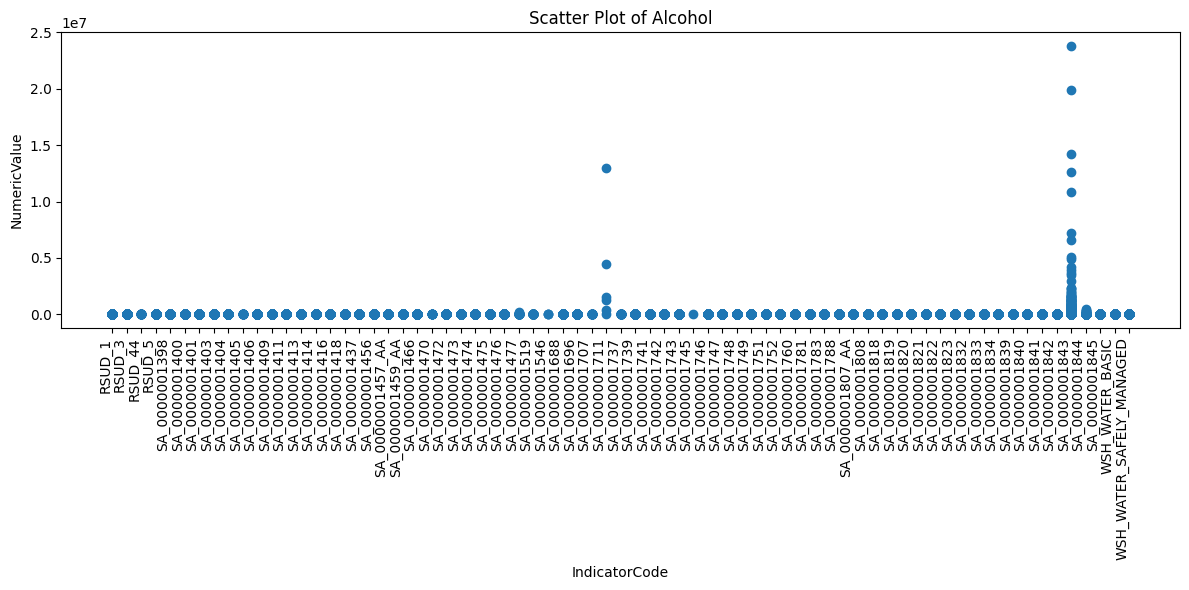

In [9]:
plt.figure(figsize=(12, 6))  # Tăng kích thước để chữ không bị chồng
plt.scatter(df['IndicatorCode'], df['NumericValue'])
plt.xlabel('IndicatorCode')
plt.ylabel('NumericValue')
plt.title('Scatter Plot of Alcohol')
plt.xticks(rotation=90, ha='right')  # rotation=90 và căn phải
plt.tight_layout()  # Tự động điều chỉnh layout
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_28452\1515023557.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=codes)


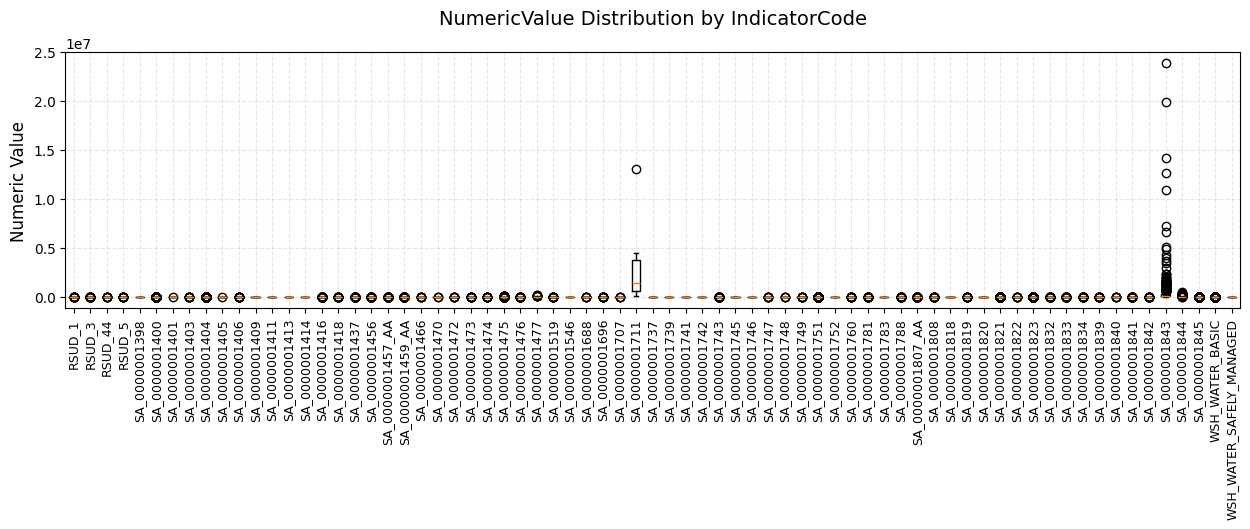

In [7]:
plt.figure(figsize=(14, 6))

codes = df['IndicatorCode'].unique()
data = [df[df['IndicatorCode'] == c]['NumericValue'] for c in codes]

plt.boxplot(data, labels=codes)
plt.xticks(rotation=90, fontsize=9)  # Xoay 90 độ và giảm font
plt.title('NumericValue Distribution by IndicatorCode', fontsize=14, pad=20)
plt.ylabel('Numeric Value', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')

# Điều chỉnh layout để nhãn không bị cắt
plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_28452\218389557.py:10: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../data/csv/alcohol_consumption.csv")
C:\Users\USER\AppData\Local\Temp\ipykernel_28452\218389557.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['NumericValue'] = df1['Value'].apply(encode_value)


Các giá trị duy nhất trong cột Value:
['No data received' 'Yes' 'No' "Don't know" 'No response' "don't know"]

Số lượng bản ghi: 970
Số quốc gia: 194
Khoảng thời gian: 2013 đến 2021

Thống kê MeanValue (tỷ lệ có kế hoạch):
count    194.000000
mean       0.646392
std        0.327832
min        0.000000
25%        0.400000
50%        0.800000
75%        1.000000
max        1.000000
Name: MeanValue, dtype: float64

Số quốc gia có dữ liệu sau khi gộp: 194

Đã load bản đồ từ đường dẫn gốc

Các cột trong bản đồ: ['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF', 'GEOUNIT', 'GU_A3', 'SU_DIF', 'SUBUNIT', 'SU_A3', 'BRK_DIFF', 'NAME', 'NAME_LONG', 'BRK_A3', 'BRK_NAME', 'BRK_GROUP', 'ABBREV', 'POSTAL', 'FORMAL_EN', 'FORMAL_FR', 'NAME_CIAWF', 'NOTE_ADM0', 'NOTE_BRK', 'NAME_SORT', 'NAME_ALT', 'MAPCOLOR7', 'MAPCOLOR8', 'MAPCOLOR9', 'MAPCOLOR13', 'POP_EST', 'POP_RANK', 'POP_YEAR', 'GDP_MD', 'GDP_YEAR', 'ECONOMY', 'INCOM

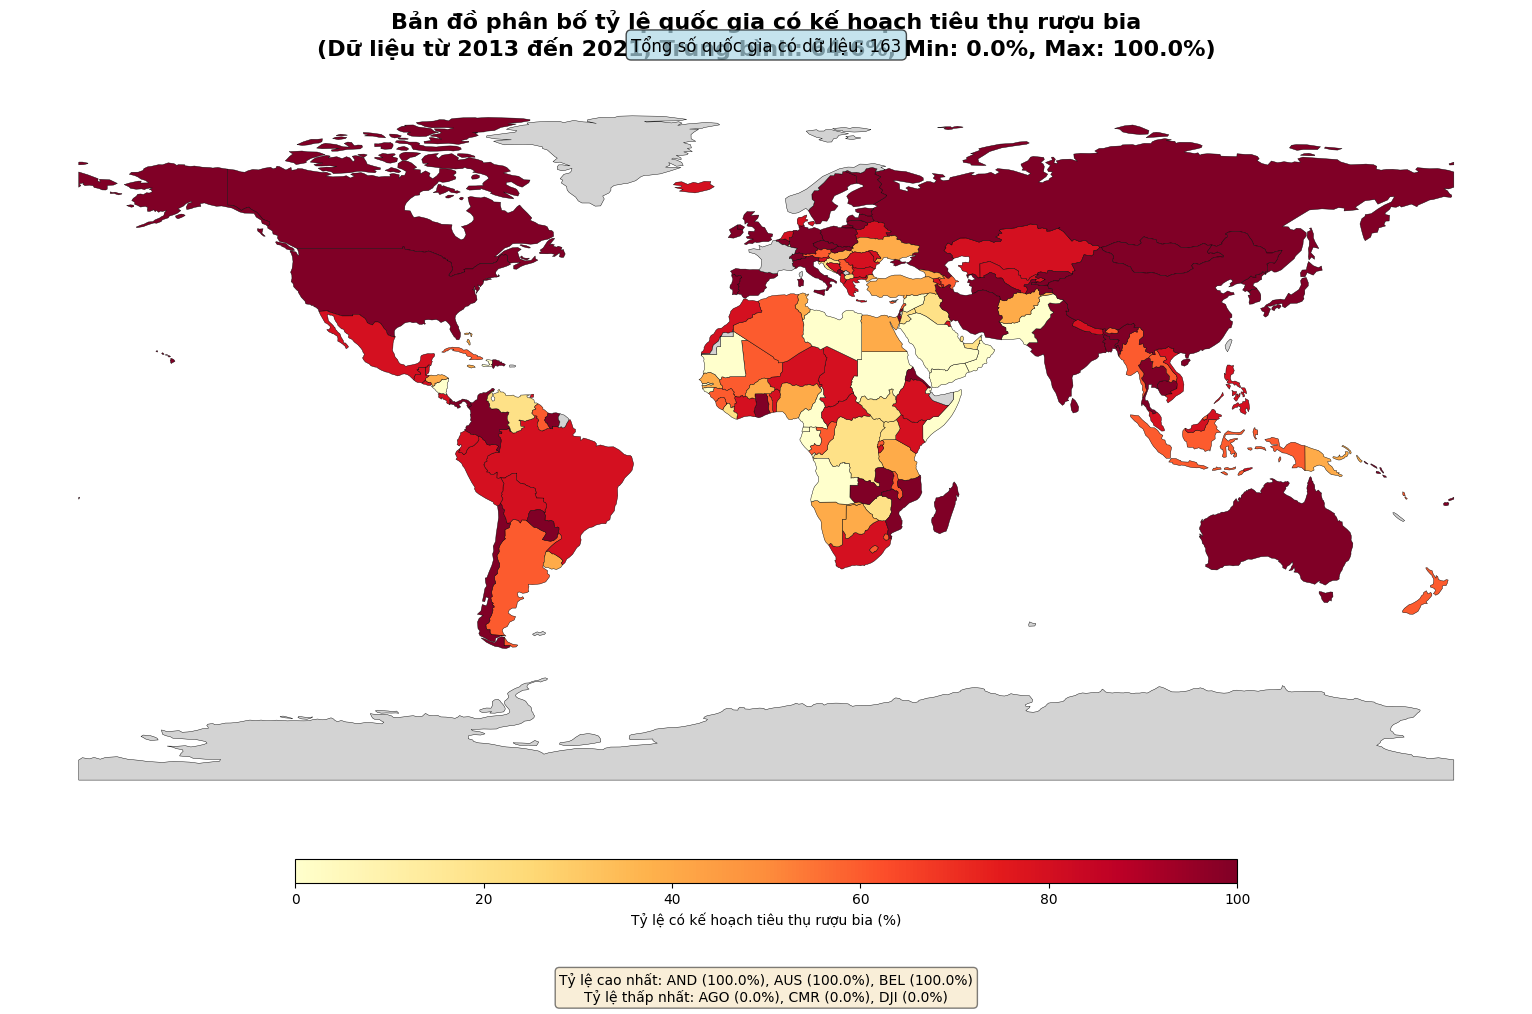

In [17]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

# ==============================
# 1. ĐỌC VÀ CHUẨN HÓA DỮ LIỆU
# ==============================
# Đọc dữ liệu từ file CSV
df = pd.read_csv("../../data/csv/alcohol_consumption.csv")

# Lọc dữ liệu cho chỉ số NCD_CCS_AlcPlan (kế hoạch tiêu thụ rượu bia)
df1 = df[df['IndicatorCode'] == 'NCD_CCS_AlcPlan']

# Kiểm tra các giá trị trong cột Value
print("Các giá trị duy nhất trong cột Value:")
print(df1['Value'].unique())
print(f"\nSố lượng bản ghi: {len(df1)}")
print(f"Số quốc gia: {df1['SpatialDim'].nunique()}")
print(f"Khoảng thời gian: {df1['TimeDimensionValue'].min()} đến {df1['TimeDimensionValue'].max()}")

# ==============================
# 2. CHUẨN HÓA DỮ LIỆU ĐỊNH TÍNH
# ==============================
# Tạo cột số hóa cho giá trị định tính
def encode_value(val):
    if pd.isna(val):
        return np.nan
    val_lower = str(val).lower().strip()
    if 'yes' in val_lower:
        return 1  # Có kế hoạch
    elif 'no' in val_lower:
        return 0  # Không có kế hoạch
    elif 'don\'t know' in val_lower or "don't know" in val_lower:
        return 0.5  # Không biết
    elif 'no data' in val_lower or 'no response' in val_lower:
        return np.nan  # Không có dữ liệu
    else:
        return np.nan  # Giá trị không xác định

# Áp dụng mã hóa
df1['NumericValue'] = df1['Value'].apply(encode_value)

# ==============================
# 3. GỘP DỮ LIỆU
# ==============================
# Nhóm dữ liệu theo quốc gia và tính tỷ lệ có kế hoạch
df_grouped = (
    df1.groupby(
        ["SpatialDim", "ParentLocationCode"],
        as_index=False
    )
    .agg(
        MeanValue=("NumericValue", "mean"),  # Tỷ lệ trung bình
        Count=("NumericValue", "count"),    # Số lượng bản ghi
        YesCount=("NumericValue", lambda x: (x == 1).sum()),  # Số lần "Yes"
        NoCount=("NumericValue", lambda x: (x == 0).sum()),   # Số lần "No"
        UnknownCount=("NumericValue", lambda x: (x == 0.5).sum())  # Số lần "Don't know"
    )
)

# Tạo cột tỷ lệ phần trăm
df_grouped['PercentYes'] = df_grouped['YesCount'] / df_grouped['Count'] * 100
df_grouped['PercentNo'] = df_grouped['NoCount'] / df_grouped['Count'] * 100
df_grouped['PercentUnknown'] = df_grouped['UnknownCount'] / df_grouped['Count'] * 100

# Kiểm tra phân bố dữ liệu
print("\nThống kê MeanValue (tỷ lệ có kế hoạch):")
print(df_grouped["MeanValue"].describe())

# Tạo cột log cho visualization (nếu cần)
df_grouped["LogPercentYes"] = np.log1p(df_grouped["PercentYes"])

print(f"\nSố quốc gia có dữ liệu sau khi gộp: {len(df_grouped)}")

# ==============================
# 4. LOAD BẢN ĐỒ & MERGE
# ==============================
try:
    # Thử load bản đồ từ đường dẫn trong code gốc
    world = gpd.read_file("../../worldmap/ne_110m_admin_0_countries.shp")
    print("\nĐã load bản đồ từ đường dẫn gốc")
except:
    try:
        # Thử load từ đường dẫn tương đối
        world = gpd.read_file("worldmap/ne_110m_admin_0_countries.shp")
        print("\nĐã load bản đồ từ đường dẫn tương đối")
    except:
        try:
            # Thử load từ package geopandas
            world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
            print("\nĐã load bản đồ từ geopandas dataset")
        except:
            print("\nKhông thể load bản đồ. Vui lòng kiểm tra đường dẫn.")
            exit()

# Kiểm tra cột mã quốc gia trong bản đồ
print("\nCác cột trong bản đồ:", world.columns.tolist())

# Merge dữ liệu với bản đồ
# SpatialDim trong dữ liệu của bạn là mã quốc gia 3 ký tự (ISO_A3)
gdf = world.merge(
    df_grouped,
    how="left",
    left_on="ISO_A3",  # Hoặc "iso_a3", "ADM0_A3" tùy vào shapefile
    right_on="SpatialDim"
)

# Nếu merge không thành công, thử với cột khác
if gdf['MeanValue'].notna().sum() == 0:
    print("\nThử merge với cột khác...")
    # Kiểm tra các cột có thể dùng để merge
    possible_cols = ['ISO_A3', 'iso_a3', 'ADM0_A3', 'ISO3', 'iso3']
    for col in possible_cols:
        if col in world.columns:
            gdf = world.merge(
                df_grouped,
                how="left",
                left_on=col,
                right_on="SpatialDim"
            )
            if gdf['MeanValue'].notna().sum() > 0:
                print(f"Merge thành công với cột: {col}")
                break

# Kiểm tra kết quả merge
print(f"\nSố quốc gia trong bản đồ: {len(world)}")
print(f"Số quốc gia sau merge: {len(gdf)}")
print(f"Số quốc gia có dữ liệu: {gdf['MeanValue'].notna().sum()}")

# ==============================
# 5. VẼ BẢN ĐỒ VỚI MÀU SẮC NHƯ CODE GỐC
# ==============================
fig, ax = plt.subplots(figsize=(16, 10))

# CHỌN COLORMAP GIỐNG NHƯ CODE GỐC
# Viridis, Plasma, YlOrRd, RdYlBu_r đều là lựa chọn tốt
# Tôi chọn YlOrRd (vàng-cam-đỏ) phù hợp với tỷ lệ phần trăm
cmap = plt.cm.YlOrRd  # Hoặc "viridis", "plasma", "RdYlBu_r"

# Vẽ bản đồ với màu sắc dựa trên PercentYes
# Lưu ý: Đã thay đổi label để phản ánh dữ liệu thực tế
gdf.plot(
    column="PercentYes", 
    ax=ax,
    legend=True,
    cmap=cmap,
    edgecolor="black",
    linewidth=0.3,
    legend_kwds={
        'label': "Tỷ lệ có kế hoạch tiêu thụ rượu bia (%)",
        'orientation': "horizontal",
        'pad': 0.05,
        'shrink': 0.6,
        'aspect': 40
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "Không có dữ liệu",
        "edgecolor": "black",
        "linewidth": 0.3
    }
)

# Thêm thông tin thống kê vào title
avg_percent = df_grouped["PercentYes"].mean()
min_percent = df_grouped["PercentYes"].min()
max_percent = df_grouped["PercentYes"].max()

title = (
    f"Bản đồ phân bố tỷ lệ quốc gia có kế hoạch tiêu thụ rượu bia\n"
    f"(Dữ liệu từ {df1['TimeDimensionValue'].min()} đến {df1['TimeDimensionValue'].max()}, "
    f"Trung bình: {avg_percent:.1f}%, Min: {min_percent:.1f}%, Max: {max_percent:.1f}%)"
)

ax.set_title(title, fontsize=16, pad=20, fontweight='bold')

# Thêm annotation cho các quốc gia có tỷ lệ cao/thấp nhất
# Tìm 3 quốc gia có tỷ lệ cao nhất và thấp nhất
top_3 = df_grouped.nlargest(3, 'PercentYes')
bottom_3 = df_grouped.nsmallest(3, 'PercentYes')

# Thêm text thông tin
info_text = (
    f"Tỷ lệ cao nhất: {top_3.iloc[0]['SpatialDim']} ({top_3.iloc[0]['PercentYes']:.1f}%), "
    f"{top_3.iloc[1]['SpatialDim']} ({top_3.iloc[1]['PercentYes']:.1f}%), "
    f"{top_3.iloc[2]['SpatialDim']} ({top_3.iloc[2]['PercentYes']:.1f}%)\n"
    f"Tỷ lệ thấp nhất: {bottom_3.iloc[0]['SpatialDim']} ({bottom_3.iloc[0]['PercentYes']:.1f}%), "
    f"{bottom_3.iloc[1]['SpatialDim']} ({bottom_3.iloc[1]['PercentYes']:.1f}%), "
    f"{bottom_3.iloc[2]['SpatialDim']} ({bottom_3.iloc[2]['PercentYes']:.1f}%)"
)

plt.figtext(0.5, 0.01, info_text, ha='center', fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# THÊM THÔNG TIN THỐNG KÊ BỔ SUNG (tương tự code gốc)
total_countries = gdf['MeanValue'].notna().sum()
stats_text = f"Tổng số quốc gia có dữ liệu: {total_countries}"
plt.figtext(0.5, 0.96, stats_text, ha='center', fontsize=12, 
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

ax.axis("off")
plt.tight_layout()
plt.show()

